In [23]:
from EarthquakeSignal import config, EarthquakeBatchProcessor
from LadrunoGraphStyle import set_default_plot_params
set_default_plot_params()

In [24]:
# pip list

### Set config manual 

In [25]:
config = {
    'file_extension': '.txt',
    'unit_factor': 9.81,
    
    'apply_baseline_correction': True,
    'apply_arias_analysis': True,
    'apply_fourier_analysis': True,
    '_compute_newmark_spectra': True,
    'compute_rotd': True,
    'print_summary': True,
    
    'plot_signals': True,
    'plot_corrected_signals': True,
    'plot_arias_signals': True,
    'plot_fourier_signals': True,  
    'plot_newmark_spectra': True,
    'plot_rotd': True,
    
    'writer': True, 
}


In [26]:
registers_path = r'data\rup_bl'


In [27]:
processor = EarthquakeBatchProcessor(registers_path, config , n_jobs=4)
earthquake = processor.process_all()


Processing earthquakes: 100%|██████████| 10/10 [00:26<00:00,  2.66s/it]


### For each earthquake


📌 Earthquake ID: 0RUPBL1
Sampling interval (dt): 0.002500 s
Number of samples: 16000
Total duration: 40.00 s
Component information:
  - H1: file='0RUPBL1_st0_X', RMS=2.7160e-02
  - H2: file='0RUPBL1_st0_Y', RMS=1.9840e-02
  - V: file='0RUPBL1_st0_Z', RMS=2.0508e-02



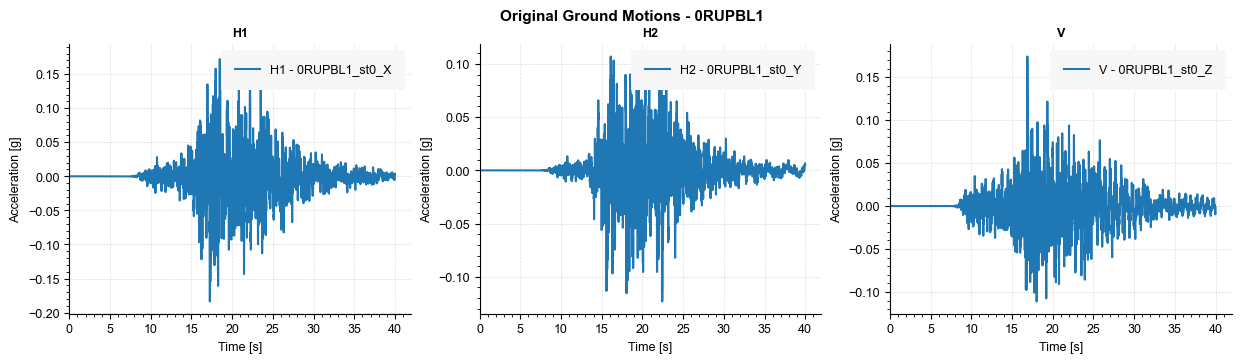

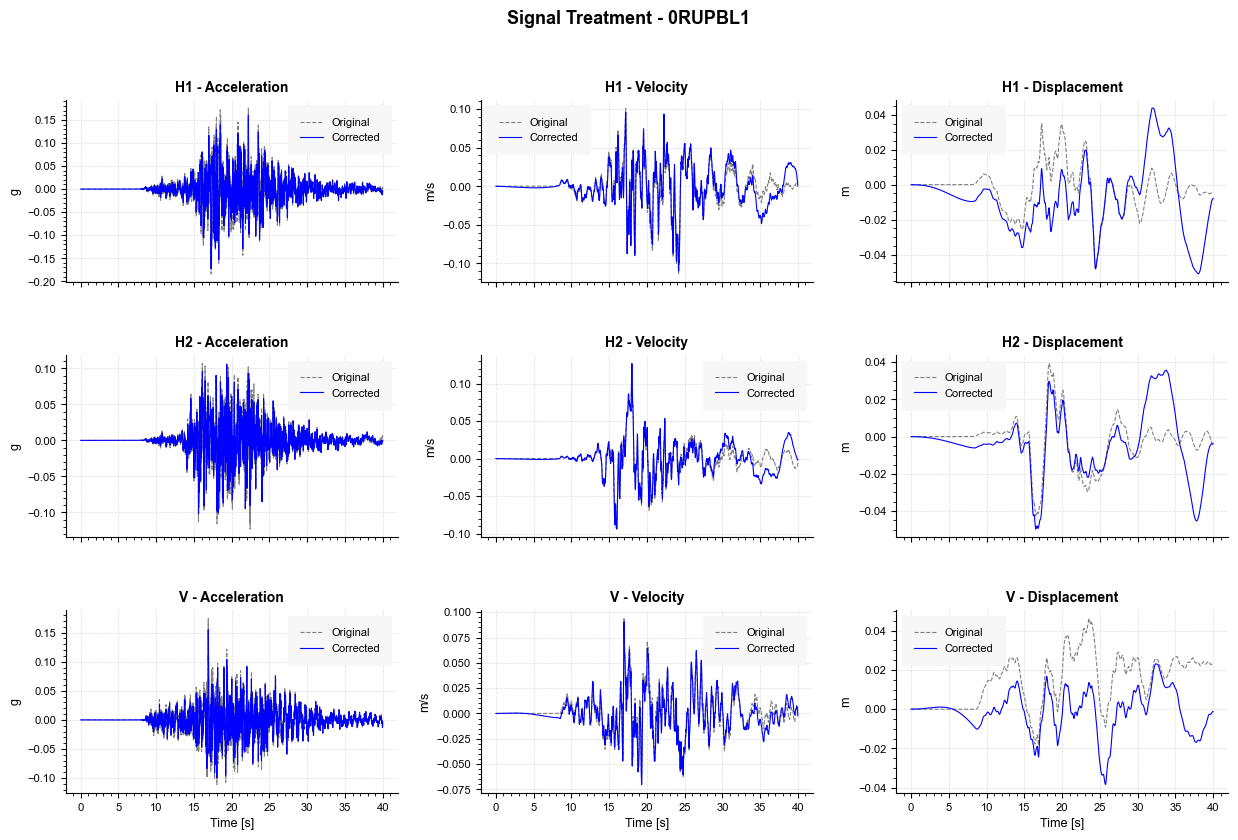

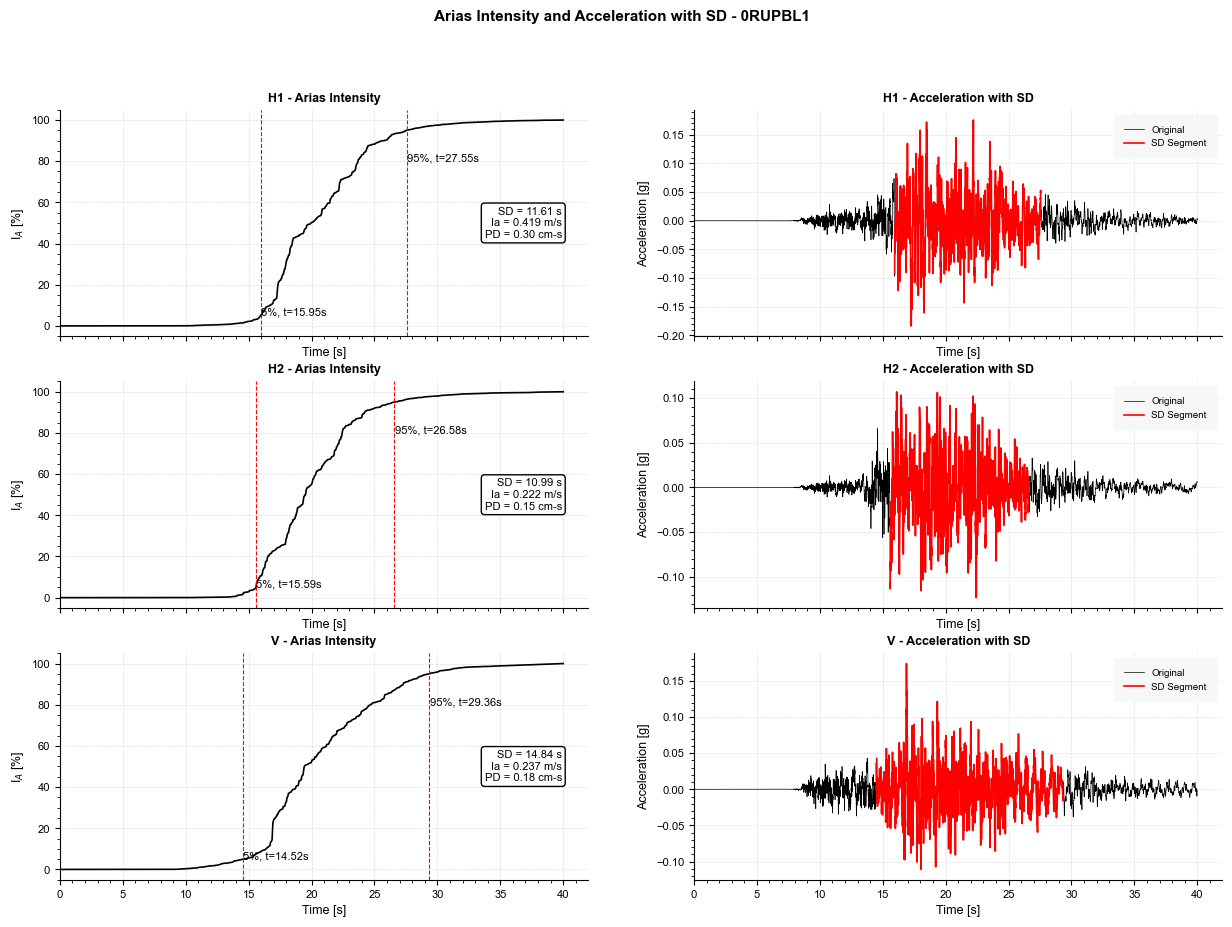

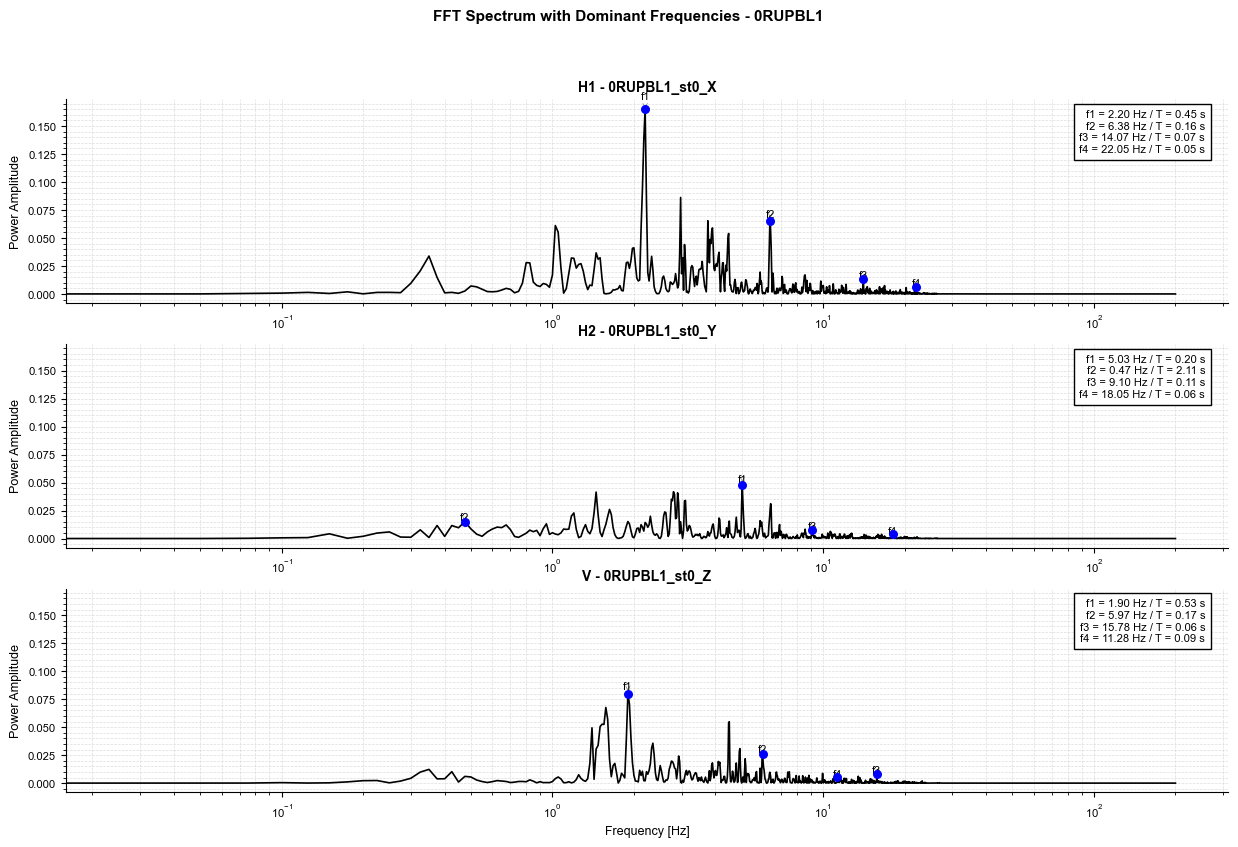

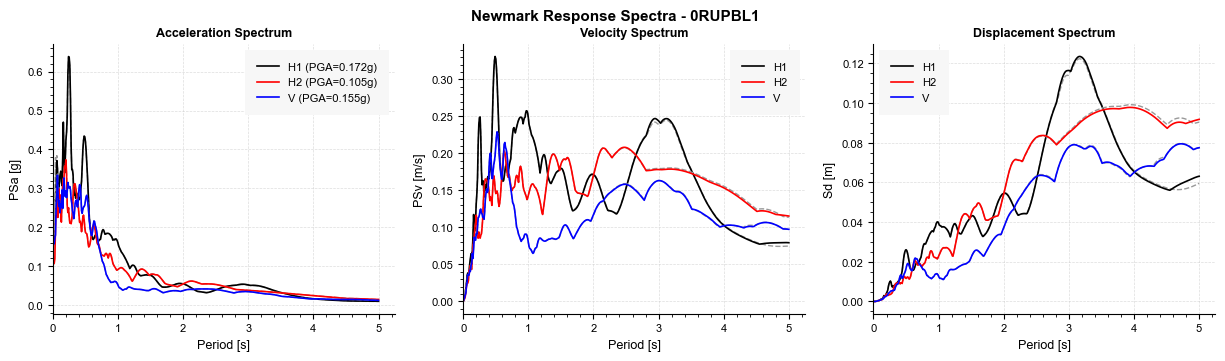

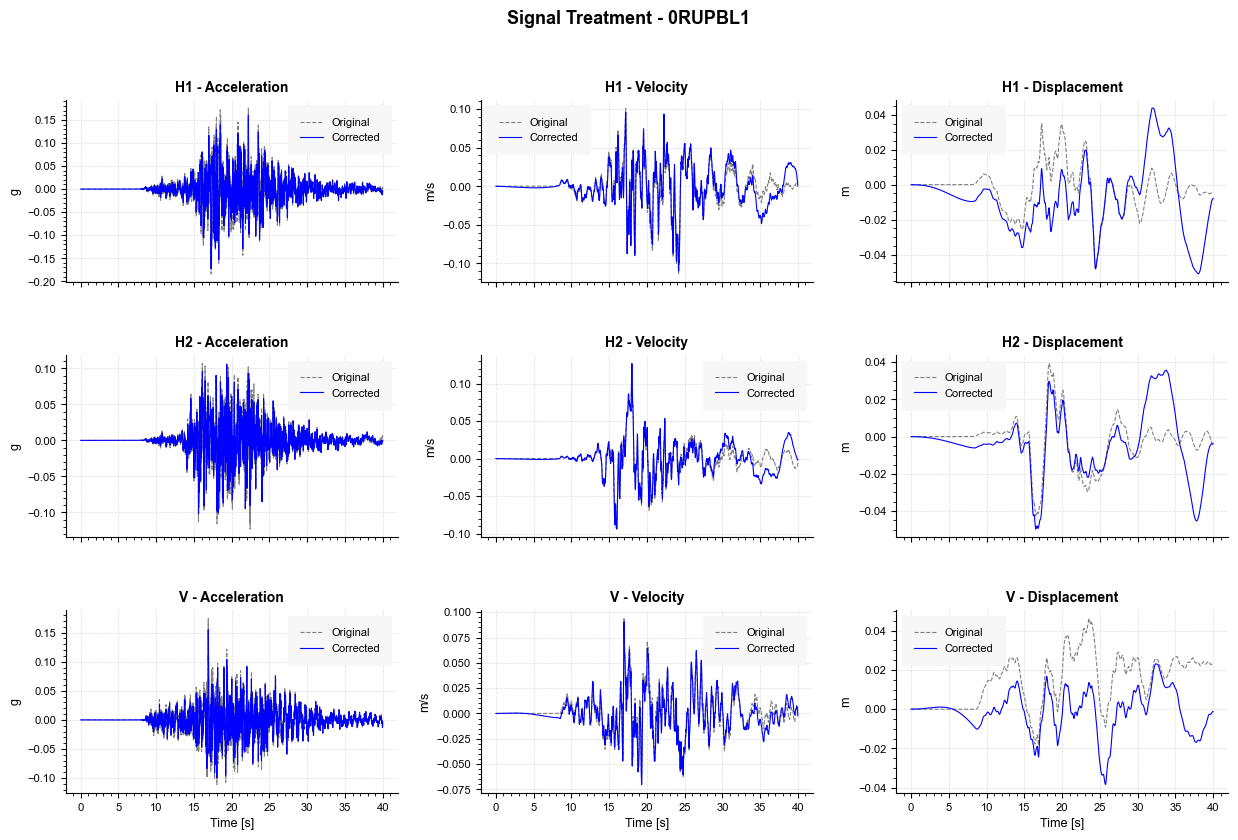

In [28]:
earthquake['0RUPBL1'].print_summary()
earthquake['0RUPBL1'].plot_original_signals()
earthquake['0RUPBL1'].plot_corrected_signals()
earthquake['0RUPBL1'].plot_arias_signals()
earthquake['0RUPBL1'].plot_fourier_signals()
earthquake['0RUPBL1'].plot_newmark_spectra()
earthquake['0RUPBL1'].plot_corrected_signals()

In [29]:
record = earthquake['0RUPBL1']


print("🔹 Arias Intensity")
print(f"Significant Duration Start  : {record.arias['H1']['t_start']:.3f} s")
print(f"Significant Duration End    : {record.arias['H1']['t_end']:.3f} s")
print(f"Total Arias Intensity       : {record.arias['H1']['IA_total']:.5f} m/s")
print(f"Destructive Potential Index : {record.arias['H1']['pot_dest']:.5f}")


print("\n🔹 Fourier Analysis")
print("Dominant Periods (s):", record.fourier['H1']['dominant_periods'])

🔹 Arias Intensity
Significant Duration Start  : 15.945 s
Significant Duration End    : 27.555 s
Total Arias Intensity       : 0.41907 m/s
Destructive Potential Index : 0.00296

🔹 Fourier Analysis
Dominant Periods (s): [0.45454545 0.15686275 0.07104796 0.04535147]


## Keys and Methods

In [30]:

first_key = next(iter(earthquake))
eq = earthquake[first_key]

print("Keys:")
for key in vars(eq):
    print(f"  - {key}")

print("\nMethods:")
import inspect
methods = [name for name, obj in inspect.getmembers(eq, inspect.ismethod) if not name.startswith('_')]
for m in methods:
    print(f"  - {m}()")

Keys:
  - filepath
  - config
  - name
  - dt
  - signals
  - component_names
  - corrected_acc
  - corrected_vel
  - corrected_disp
  - arias
  - newmark_spectra
  - rotd
  - fourier
  - summary_tool
  - plotter_tool
  - comparison_tool
  - arias_plotter
  - fourier_plotter
  - newmark_plotter
  - rotd_plotter
  - exporter
  - signals_raw

Methods:
  - export()
  - load_and_process()
  - plot_arias_signals()
  - plot_corrected_signals()
  - plot_fourier_signals()
  - plot_newmark_spectra()
  - plot_original_signals()
  - plot_rotd()
  - print_summary()


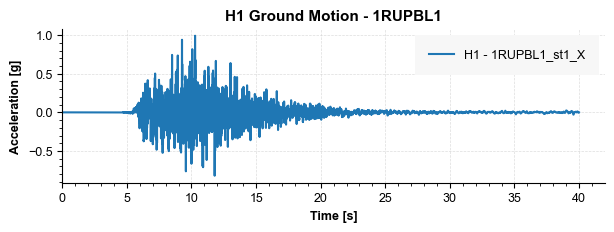

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Datos
acel = earthquake['1RUPBL1'].signals['H1']
dt = earthquake['1RUPBL1'].dt
name = earthquake['1RUPBL1'].name
label = earthquake['1RUPBL1'].component_names['H1']

# Eje de tiempo
time = np.arange(len(acel)) * dt

# Crear figura
plt.figure(figsize=(7, 2))
plt.plot(time, acel, label=f"H1 - {label}", linewidth=1.5)

# Formato
plt.xlabel('Time [s]', fontsize=9, fontweight='bold')
plt.ylabel('Acceleration [g]', fontsize=9, fontweight='bold')
plt.title(f"H1 Ground Motion - {name}", fontsize=11, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tick_params(axis='both', labelsize=9)
plt.grid(True)
plt.xlim(left=0)

# Guardar como SVG (opcional)
save_svg = True
if save_svg:
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
    output_path = os.path.join(project_root, 'outputs', name)
    os.makedirs(output_path, exist_ok=True)
    file_path = os.path.join(output_path, "H1_ground_motion.svg")
    plt.savefig(file_path, format="svg")

# Mostrar
plt.show()


### All spectra

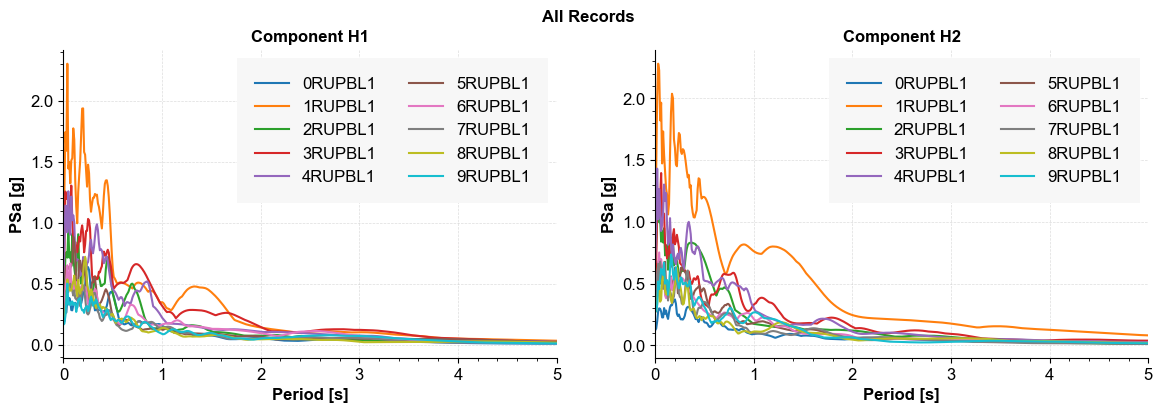

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import os


# --- Graficar espectros ---
plt.figure(figsize=(14, 4))

# Subplot para H1
plt.subplot(1, 2, 1)
for rsn, eq in earthquake.items():
    try:
        T_H1 = eq.newmark_spectra['H1']['T']
        PSa_H1 = eq.newmark_spectra['H1']['PSa']
        plt.plot(T_H1, PSa_H1, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H1 spectrum")

plt.title("Component H1", fontweight='bold', fontsize=12)
plt.xlabel("Period [s]", fontweight='bold', fontsize=12)
plt.ylabel("PSa [g]", fontweight='bold', fontsize=12)
plt.grid(True)
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
plt.legend(loc='upper right', ncol=2, fontsize=12)

# Subplot para H2
plt.subplot(1, 2, 2)
for rsn, eq in earthquake.items():
    try:
        T_H2 = eq.newmark_spectra['H2']['T']
        PSa_H2 = eq.newmark_spectra['H2']['PSa']
        plt.plot(T_H2, PSa_H2, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H2 spectrum")

plt.title("Component H2", fontweight='bold', fontsize=12)
plt.xlabel("Period [s]", fontweight='bold', fontsize=12)
plt.ylabel("PSa [g]", fontweight='bold', fontsize=12)
plt.grid(True)
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=12)
plt.legend(loc='upper right', ncol=2, fontsize=12)

plt.suptitle("All Records", fontsize=12, fontweight='bold')

plt.show()


### Rotd100

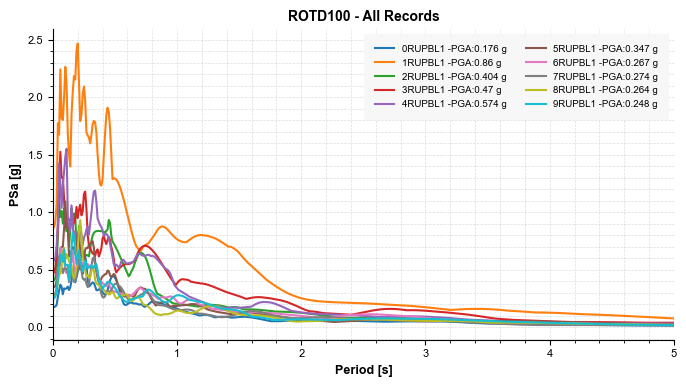

In [33]:


# Create figure with 1 row and 1 column
plt.figure(figsize=(7, 4))

# Subplot for ROTD100
plt.subplot(1, 1, 1)
for rsn, eq in earthquake.items():
    try:

        T = eq.rotd['T']
        PSa_rotd100 = eq.rotd['ROTD100']
        pga = round(PSa_rotd100[0], 3)
        plt.plot(T, PSa_rotd100, linewidth=1.5, label=f"{rsn} -PGA:{pga} g")
    except KeyError:
        print(f"Warning: {rsn} missing ROTD100 spectrum")

plt.title("ROTD100 - All Records", fontsize=10, fontweight='bold')
plt.xlabel("Period [s]", fontsize=9, fontweight='bold')
plt.ylabel("PSa [g]", fontsize=9, fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=8)
plt.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


### Data extract

In [34]:
import pandas as pd
import numpy as np

rows = []
for rsn, eq in earthquake.items():
    name = getattr(eq, "name", str(rsn))
    dt = getattr(eq, "dt", None)
    first_signal = next(iter(eq.signals.values()))
    n_samples = len(first_signal)
    total_duration = n_samples * dt

    H1_file = eq.component_names.get('H1', None) 
    H2_file = eq.component_names.get('H2', None) 
    V_file  = eq.component_names.get('V', None)

    # Significant Duration (SD) and Arias parameters
    H1_SD = eq.arias['H1']['t_end'] - eq.arias['H1']['t_start']
    H1_IA_total = eq.arias['H1']['IA_total']
    H1_pot_dest = eq.arias['H1']['pot_dest']

    H2_SD = eq.arias['H2']['t_end'] - eq.arias['H2']['t_start']
    H2_IA_total = eq.arias['H2']['IA_total']
    H2_pot_dest = eq.arias['H2']['pot_dest']

    V_SD = eq.arias['V']['t_end'] - eq.arias['V']['t_start']
    V_IA_total = eq.arias['V']['IA_total']
    V_pot_dest = eq.arias['V']['pot_dest']

    # First dominant peak
    H1_peak1 = eq.fourier['H1']['dominant_periods'][0]
    H2_peak1 = eq.fourier['H2']['dominant_periods'][0]
    V_peak1  = eq.fourier['V']['dominant_periods'][0]

    # PGA = first value of PSa_corr
    H1_PGA = eq.newmark_spectra['H1']['PSa_corr'][0]
    H2_PGA = eq.newmark_spectra['H2']['PSa_corr'][0]
    V_PGA  = eq.newmark_spectra['V']['PSa_corr'][0]

    rows.append({
        "record_id": str(rsn),
        "name": name,
        "dt": dt,
        "n_samples": n_samples,
        "total_duration": total_duration,
        "H1_file": H1_file, "H1_SD": H1_SD, "H1_IA_total": H1_IA_total, "H1_pot_dest": H1_pot_dest*100, "H1_peak1": H1_peak1, "H1_PGA": H1_PGA,
        "H2_file": H2_file, "H2_SD": H2_SD, "H2_IA_total": H2_IA_total, "H2_pot_dest": H2_pot_dest*100, "H2_peak1": H2_peak1, "H2_PGA": H2_PGA,
        "V_file":  V_file,  "V_SD": V_SD,  "V_IA_total": V_IA_total,  "V_pot_dest": V_pot_dest*100,  "V_peak1": V_peak1,  "V_PGA": V_PGA
    })

df_records = pd.DataFrame(rows).sort_values("record_id").reset_index(drop=True)

print("✅ Registros encontrados:", len(df_records))
print(df_records.head(10))


✅ Registros encontrados: 10
  record_id     name      dt  n_samples  total_duration        H1_file  \
0   0RUPBL1  0RUPBL1  0.0025      16000            40.0  0RUPBL1_st0_X   
1   1RUPBL1  1RUPBL1  0.0025      16000            40.0  1RUPBL1_st1_X   
2   2RUPBL1  2RUPBL1  0.0025      16000            40.0  2RUPBL1_st2_X   
3   3RUPBL1  3RUPBL1  0.0025      16000            40.0  3RUPBL1_st3_X   
4   4RUPBL1  4RUPBL1  0.0025      16000            40.0  4RUPBL1_st4_X   
5   5RUPBL1  5RUPBL1  0.0025      16000            40.0  5RUPBL1_st5_X   
6   6RUPBL1  6RUPBL1  0.0025      16000            40.0  6RUPBL1_st6_X   
7   7RUPBL1  7RUPBL1  0.0025      16000            40.0  7RUPBL1_st7_X   
8   8RUPBL1  8RUPBL1  0.0025      16000            40.0  8RUPBL1_st8_X   
9   9RUPBL1  9RUPBL1  0.0025      16000            40.0  9RUPBL1_st9_X   

     H1_SD  H1_IA_total  H1_pot_dest  H1_peak1  ...  H2_IA_total H2_pot_dest  \
0  11.6100     0.419070     0.295896  0.454545  ...     0.221791    0.152727 

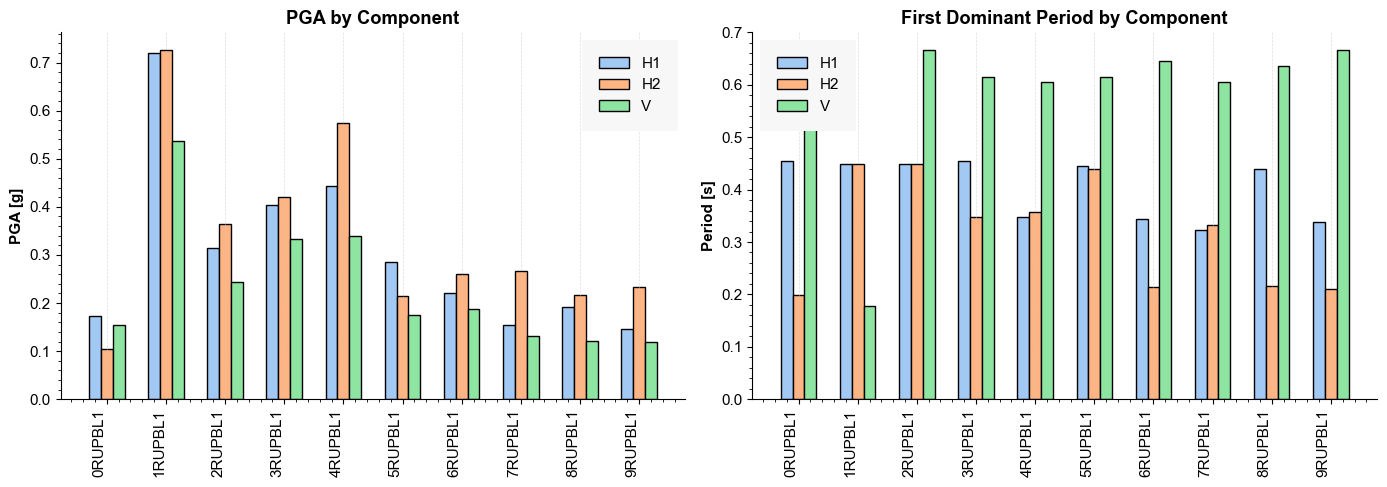

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Posiciones en X
x = np.arange(len(df_records))
bar_width = 0.20

# Colores pastel suaves
color_h1 = "#a1c9f4"  # pastel azul
color_h2 = "#ffb482"  # pastel naranja
color_v  = "#8de5a1"  # pastel verde

# Figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ----------------------
# Subplot 1: PGA
# ----------------------
ax1.bar(x - bar_width, df_records["H1_PGA"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax1.bar(x,             df_records["H2_PGA"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax1.bar(x + bar_width, df_records["V_PGA"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax1.set_title("PGA by Component", fontweight="bold")
ax1.set_ylabel("PGA [g]", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax1.grid(axis="y")
ax1.legend()

# ----------------------
# Subplot 2: Dominant Period
# ----------------------
ax2.bar(x - bar_width, df_records["H1_peak1"], width=bar_width, label="H1", color=color_h1, edgecolor="black")
ax2.bar(x,             df_records["H2_peak1"], width=bar_width, label="H2", color=color_h2, edgecolor="black")
ax2.bar(x + bar_width, df_records["V_peak1"],  width=bar_width, label="V",  color=color_v,  edgecolor="black")

ax2.set_title("First Dominant Period by Component", fontweight="bold")
ax2.set_ylabel("Period [s]", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(df_records["name"], rotation=90, ha="right")
ax2.grid(axis="y")
ax2.legend()

plt.tight_layout()
plt.show()


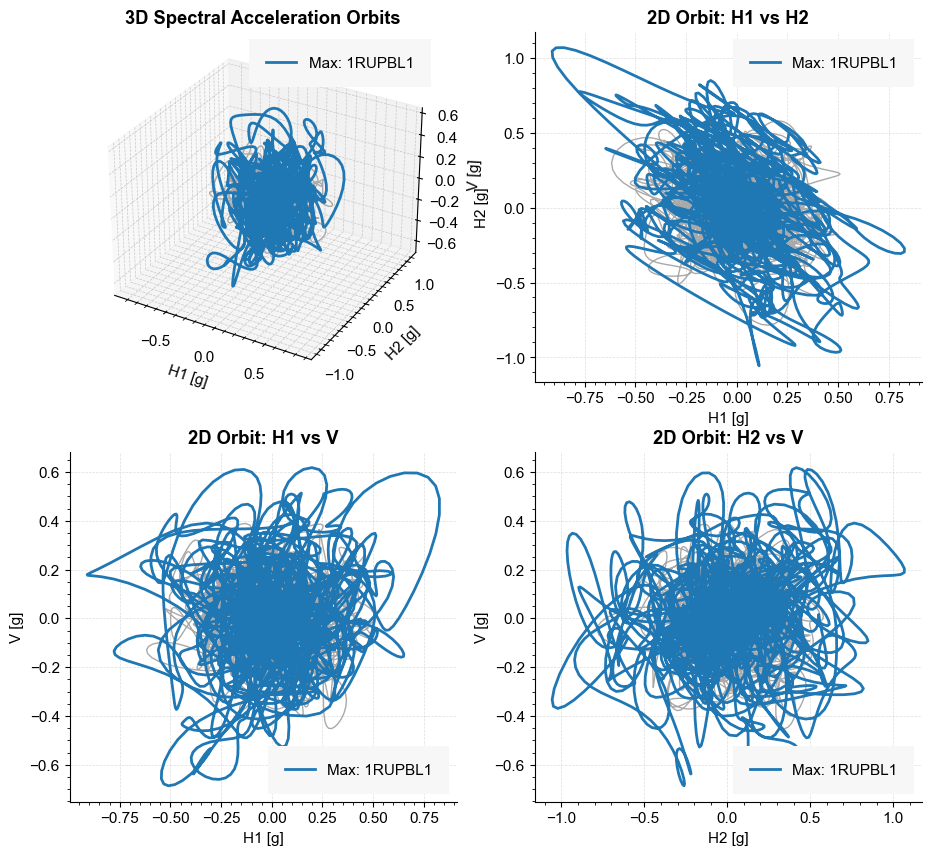

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ========== Preprocesamiento ==========
max_r_by_record = {}
all_orbits_3d = {}

for rsn, eq in earthquake.items():
    try:
        a1 = eq.newmark_spectra["H1"]["a_corr"]
        a2 = eq.newmark_spectra["H2"]["a_corr"]
        a3 = eq.newmark_spectra["V"]["a_corr"]
    except KeyError:
        continue

    n = min(len(a1), len(a2), len(a3))
    a1 = np.array(a1[:n])
    a2 = np.array(a2[:n])
    a3 = np.array(a3[:n])

    r = np.sqrt(a1**2 + a2**2 + a3**2)
    max_r = np.max(r)
    max_r_by_record[rsn] = max_r
    all_orbits_3d[rsn] = (a1, a2, a3)

max_rsn = max(max_r_by_record, key=max_r_by_record.get)
a1_max, a2_max, a3_max = all_orbits_3d[max_rsn]

# ========== Figure con 4 subplots ==========
fig = plt.figure(figsize=(11, 10))

# Subplot 1: 3D ORBIT (H1, H2, V)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
for rsn, (a1, a2, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax1.plot(a1, a2, a3, color='darkgray', linewidth=1)
ax1.plot(a1_max, a2_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax1.set_title("3D Spectral Acceleration Orbits", fontweight="bold")
ax1.set_xlabel("H1 [g]")
ax1.set_ylabel("H2 [g]")
ax1.set_zlabel("V [g]")
ax1.legend()

# Subplot 2: PLANTA (H1 vs H2)
ax2 = fig.add_subplot(2, 2, 2)
for rsn, (a1, a2, _) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax2.plot(a1, a2, color='darkgray', linewidth=1)
ax2.plot(a1_max, a2_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax2.set_title("2D Orbit: H1 vs H2", fontweight="bold")
ax2.set_xlabel("H1 [g]")
ax2.set_ylabel("H2 [g]")
ax2.grid(True)
ax2.legend()

# Subplot 3: VISTA LATERAL YZ (H1 vs V)
ax3 = fig.add_subplot(2, 2, 3)
for rsn, (a1, _, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax3.plot(a1, a3, color='darkgray', linewidth=1)
ax3.plot(a1_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax3.set_title("2D Orbit: H1 vs V", fontweight="bold")
ax3.set_xlabel("H1 [g]")
ax3.set_ylabel("V [g]")
ax3.grid(True)
ax3.legend()

# Subplot 4: VISTA LATERAL XZ (H2 vs V)
ax4 = fig.add_subplot(2, 2, 4)
for rsn, (_, a2, a3) in all_orbits_3d.items():
    if rsn == max_rsn:
        continue
    ax4.plot(a2, a3, color='darkgray', linewidth=1)
ax4.plot(a2_max, a3_max, color='tab:blue', linewidth=2.0, label=f"Max: {max_rsn}")
ax4.set_title("2D Orbit: H2 vs V", fontweight="bold")
ax4.set_xlabel("H2 [g]")
ax4.set_ylabel("V [g]")
ax4.grid(True)
ax4.legend()

# Mostrar

plt.show()
